In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

# Scikit-learn imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

# TensorFlow and Keras imports
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.config.experimental import list_physical_devices, set_memory_growth
from tensorflow import device

# Suppress warnings
warnings.filterwarnings('ignore')
plt.rc('font',family='Times New Roman')

In [3]:
def make_dataset(data_src):
    """Loads all CSV files from a directory and returns a DataFrame."""
    files = glob.glob(data_src)
    dataset_df = []
    
    for file in files:
        if os.path.isfile(file) and file.endswith(".csv"):
            # read only the 2nd column (index 1)
            col = pd.read_csv(file, header=None, usecols=[1])
            dataset_df.append(col)
    
    if not dataset_df:
        print(f"Warning: No CSV files found in {data_src}")
        return pd.DataFrame()
        
    dataset = pd.concat(dataset_df, ignore_index=True, axis=1)
    return dataset.T

In [16]:
# --- 1. Load Data ---
data_path = ("../data/Wave Data/") # path to the 5 folders.
A = make_dataset(os.path.join(data_path, 'A/*'))
B = make_dataset(os.path.join(data_path, 'B/*'))
C = make_dataset(os.path.join(data_path, 'C/*'))
D = make_dataset(os.path.join(data_path, 'D/*'))
E = make_dataset(os.path.join(data_path, 'E/*')) # Seizure data

# --- 2. Combine and Create Labels ---
# Normal (non-seizure) data
normal = pd.concat([A, B, C, D]).reset_index(drop=True).to_numpy()
# Ictal (seizure) data
ictal = E.to_numpy()

normal_labels = np.zeros(len(normal))
ictal_labels = np.ones(len(ictal))

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print("Data scaled using StandardScaler (fit on train data only).")

# --- 5. Reshape for RNN ---
# Reshape data from (samples, timesteps) to (samples, timesteps, features)
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_val = np.reshape(X_val, (X_val.shape[0], X_val.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

print(f"Reshaped X_train: {X_train.shape}")

# Define model input parameters
timesteps = X_train.shape[1]  # <-- This line defines timesteps
features = X_train.shape[2]   # <-- This line now works because X_train is 3D

# Combine data and labels
X = np.concatenate((normal, ictal), axis=0)
Y = np.concatenate((normal_labels, ictal_labels), axis=0)

print(f"Total X shape: {X.shape}")
print(f"Total Y shape: {Y.shape}")

# --- 3. Split Data ---
# Create Test set (30%)
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.3, shuffle=True, stratify=Y, random_state=42
)

# Create Validation set from remaining training data (10% of 70% = 7% of total)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.1, shuffle=True, stratify=y_train, random_state=42
)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_val shape:   {X_val.shape}")
print(f"y_val shape:   {y_val.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_test shape:  {y_test.shape}")

Data scaled using StandardScaler (fit on train data only).
Reshaped X_train: (315, 4097, 1)
Total X shape: (500, 4097)
Total Y shape: (500,)
X_train shape: (315, 4097)
y_train shape: (315,)
X_val shape:   (35, 4097)
y_val shape:   (35,)
X_test shape:  (150, 4097)
y_test shape:  (150,)


In [18]:
# This dictionary maps the integer indices from 'best' back to the real values
# It matches the 'space' dictionary you provided.
values = {
    'units0': [16, 32, 64, 128],
    'units1': [16, 32, 64, 128],
    'units2': [16, 32, 64, 128],
    'units3': [16, 32, 64, 128],
    'dense_units': [16, 32, 64, 128],
}

# These are the 'best' results from your fmin run
best = {
    'dense_units': np.int64(2), 
    'dropout0': np.float64(0.365677421983949), 
    'dropout1': np.float64(0.38652676771624195), 
    'lr': np.float64(9.439669121552798e-05), 
    'units0': np.int64(3), 
    'units1': np.int64(2), 
    'units2': np.int64(2), 
    'units3': np.int64(2)
}

# This translates the 'best' indices into the final hyperparameter values
optimized_values = {
    'units0': values['units0'][best['units0']],
    'units1': values['units1'][best['units1']],
    'units2': values['units2'][best['units2']],
    'units3': values['units3'][best['units3']],
    'dense_units': values['dense_units'][best['dense_units']],
    'dropout0': best['dropout0'],
    'dropout1': best['dropout1'],
    'lr': best['lr']
}

print("--- Optimized Hyperparameters ---")
print(optimized_values)

--- Optimized Hyperparameters ---
{'units0': 128, 'units1': 64, 'units2': 64, 'units3': 64, 'dense_units': 64, 'dropout0': np.float64(0.365677421983949), 'dropout1': np.float64(0.38652676771624195), 'lr': np.float64(9.439669121552798e-05)}


In [20]:
# 1. Define the model using your 'optimized_values'
# NOTE: This is a 4-layer LSTM to match your search space
model = Sequential([
    LSTM(optimized_values['units0'], return_sequences=True, input_shape=(timesteps, features)),  
    LSTM(optimized_values['units1'], return_sequences=True),
    LSTM(optimized_values['units2'], return_sequences=True),
    LSTM(optimized_values['units3'], return_sequences=False), # Last LSTM layer
    Dropout(optimized_values['dropout0']),
    Dense(optimized_values['dense_units'], activation='relu'), 
    Dropout(optimized_values['dropout1']),
    Dense(1, activation='sigmoid') # Final output
])

# 2. Compile the model with the optimized learning rate
model.compile(
    optimizer=Adam(learning_rate=optimized_values['lr']), 
    loss='binary_crossentropy', 
    metrics=['accuracy']
)

# 3. Set up callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# This is the name of the weights file your search created
checkpoint = ModelCheckpoint(
    '../weights/Optimized_LSTM.weights.h5', 
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=True
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 4097, 128)      │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 4097, 64)       │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 4097, 64)       │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 186,241 (727.50 KB)

 Trainable params: 186,241 (727.50 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
with device('/GPU:0'):
    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=50,
        batch_size = 20,
        callbacks= [early_stopping, checkpoint]
    )

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 117s 7s/step - accuracy: 0.4502 - loss: 0.6981 - val_accuracy: 0.8000 - val_loss: 0.6422
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 117s 7s/step - accuracy: 0.7340 - loss: 0.6489 - val_accuracy: 0.8000 - val_loss: 0.5847
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 109s 7s/step - accuracy: 0.8090 - loss: 0.5800 - val_accuracy: 0.8000 - val_loss: 0.5073
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 104s 7s/step - accuracy: 0.7786 - loss: 0.5182 - val_accuracy: 0.8000 - val_loss: 0.3962
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 97s 6s/step - accuracy: 0.8151 - loss: 0.4570 - val_accuracy: 0.9429 - val_loss: 0.2839
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 102s 6s/step - accuracy: 0.9299 - loss: 0.3099 - val_accuracy: 0.9714 - val_loss: 0.2280
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 103s 6s/step - accuracy: 0.9146 - loss: 0.2838 - val_accuracy: 0.9714 - val_loss: 0.2133
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 110s 7s/step - accuracy: 0.9255 - loss: 0.2441 - val_accuracy: 0.9714 - va

In [23]:
print("--- Loading best weights for evaluation ---")
model.load_weights('../weights/Optimized_LSTM.weights.h5')

test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

# Get predictions (probabilities)
y_pred_prob = model.predict(X_test)

--- Loading best weights for evaluation ---
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.9039 - loss: 0.2403
Test Loss: 0.18659064173698425
Test Accuracy: 0.9266666769981384
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step


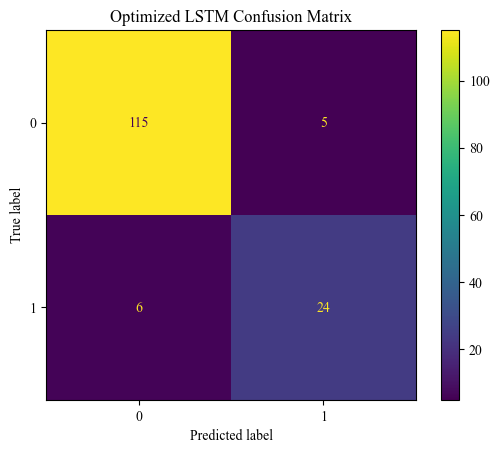


--- Classification Report ---
              precision    recall  f1-score   support

         0.0       0.95      0.96      0.95       120
         1.0       0.83      0.80      0.81        30

    accuracy                           0.93       150
   macro avg       0.89      0.88      0.88       150
weighted avg       0.93      0.93      0.93       150



In [24]:
# Convert probabilities to class labels (0 or 1)
y_pred = (y_pred_prob > 0.5).astype("int32")

# y_test is already 1D, no argmax needed
y_test_classes = y_test

# Compute confusion matrix
cm = confusion_matrix(y_test_classes, y_pred)

# Display confusion matrix
display_labels = [0, 1] 
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
cm_display.plot()
plt.title("Optimized LSTM Confusion Matrix")
plt.show()

# Print classification report
print("\n--- Classification Report ---")
print(classification_report(y_test_classes, y_pred))

In [25]:
import numpy as np

# --- You can change this index to test different samples ---
sample_index = 0
# ------------------------------------------------------------

# Get a single sample from the test set (it's already normalized and reshaped)
sample = X_test[np.newaxis, sample_index]

# Get the corresponding true label (it's a 1D array)
true_label_index = y_test[sample_index].astype("int32")

# Use the 'model' to predict.
prediction_prob = model.predict(sample)[0][0]

# Get the predicted class index by thresholding
predicted_label_index = (prediction_prob > 0.5).astype("int32")

# Define the class names
class_names = ['Class 0 (Normal)', 'Class 1 (Seizure)']

# Print the results
print(f"--- Testing Sample #{sample_index} ---")
print(f"Model Prediction: {class_names[predicted_label_index]} (Prob: {prediction_prob:.4f})")
print(f"Actual Label:     {class_names[true_label_index]}")

if predicted_label_index == true_label_index:
    print("\nResult: Correctly Identified!")
else:
    print("\nResult: Incorrectly Identified.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step
--- Testing Sample #0 ---
Model Prediction: Class 0 (Normal) (Prob: 0.0201)
Actual Label:     Class 0 (Normal)

Result: Correctly Identified!


In [30]:
from art.attacks.evasion import FastGradientMethod
from art.estimators.classification import TensorFlowV2Classifier
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import tensorflow as tf
from tensorflow.keras import backend as K

In [32]:
# 1. Get the min/max values from your normalized test data (from Cell 3)
clip_min = X_test.min()
clip_max = X_test.max()

# 2. Wrap your 'model' (defined in Cell 8)
# We use the standard 'categorical_crossentropy' loss it was compiled with (in Cell 9).
art_classifier = TensorFlowV2Classifier(
    model=model,
    nb_classes=2,
    input_shape=(1733, 1), # Use the correct input shape from Cell 8
    loss_object=tf.keras.losses.CategoricalCrossentropy(), # Use the loss from Cell 9
    clip_values=(clip_min, clip_max)
)

print("ART Classifier wrapped successfully.")

ART Classifier wrapped successfully.


In [38]:
# 1. Create the FGM attack with a moderate strength
attack_fgm = FastGradientMethod(estimator=art_classifier, eps=0.1)

# 2. Generate adversarial examples from your clean X_test
print("Generating adversarial examples for eps=0.1...")
X_test_adv = attack_fgm.generate(x=X_test)
print("Generation complete.")

# 3. Evaluate on CLEAN data (Baseline)
preds_clean = model.predict(X_test)
preds_clean_classes = np.argmax(preds_clean, axis=1)

# --- FIX IS HERE ---
# The error indicates y_test is already 1D (labels), not 2D (one-hot).
# We can use it directly instead of taking np.argmax.
y_test_classes = y_test
# --- END FIX ---

acc_clean = np.mean(preds_clean_classes == y_test_classes)
print(f"\nAccuracy on CLEAN data (Baseline):   {acc_clean * 100:.2f}%")

# 4. Evaluate on ADVERSARIAL data
preds_adv = model.predict(X_test_adv)
preds_adv_classes = np.argmax(preds_adv, axis=1)

acc_adv = np.mean(preds_adv_classes == y_test_classes)
print(f"Accuracy on ADVERSARIAL data (FGM):  {acc_adv * 100:.2f}%")

Generating adversarial examples for eps=0.1...
Generation complete.
5/5 ━━━━━━━━━━━━━━━━━━━━ 14s 3s/step

Accuracy on CLEAN data (Baseline):   80.00%
5/5 ━━━━━━━━━━━━━━━━━━━━ 13s 3s/step
Accuracy on ADVERSARIAL data (FGM):  80.00%



--- ADVERSARIAL Classification Report (eps=0.1) ---
                   precision    recall  f1-score   support

 Class 0 (Normal)       0.80      1.00      0.89       120
Class 1 (Seizure)       0.00      0.00      0.00        30

         accuracy                           0.80       150
        macro avg       0.40      0.50      0.44       150
     weighted avg       0.64      0.80      0.71       150


--- ADVERSARIAL Confusion Matrix (eps=0.1) ---


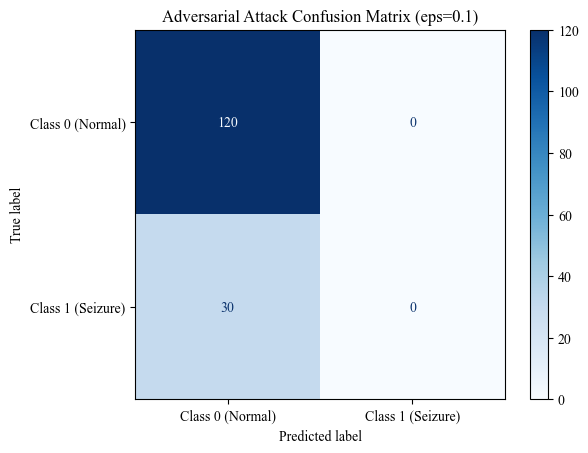

In [39]:
print("\n--- ADVERSARIAL Classification Report (eps=0.1) ---")
target_names = ['Class 0 (Normal)', 'Class 1 (Seizure)']

# --- FIX IS HERE ---
# y_test is already 1D, so we use it directly
y_test_classes = y_test
# --- END FIX ---

print(classification_report(y_test_classes, preds_adv_classes, target_names=target_names))

print("\n--- ADVERSARIAL Confusion Matrix (eps=0.1) ---")
cm_adv = confusion_matrix(y_test_classes, preds_adv_classes)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm_adv, display_labels=target_names)

cm_display.plot(cmap=plt.cm.Blues)
plt.title("Adversarial Attack Confusion Matrix (eps=0.1)")
plt.show()

Evaluating model robustness across different eps values...
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step
eps=0.000 → Accuracy=80.00%
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step
eps=0.033 → Accuracy=80.00%
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step
eps=0.067 → Accuracy=80.00%
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step
eps=0.100 → Accuracy=80.00%
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step
eps=0.133 → Accuracy=80.00%
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step
eps=0.167 → Accuracy=80.00%
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step
eps=0.200 → Accuracy=80.00%
5/5 ━━━━━━━━━━━━━━━━━━━━ 15s 3s/step
eps=0.233 → Accuracy=80.00%
5/5 ━━━━━━━━━━━━━━━━━━━━ 17s 3s/step
eps=0.267 → Accuracy=80.00%
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step
eps=0.300 → Accuracy=80.00%

Baseline accuracy on CLEAN data: 80.00%


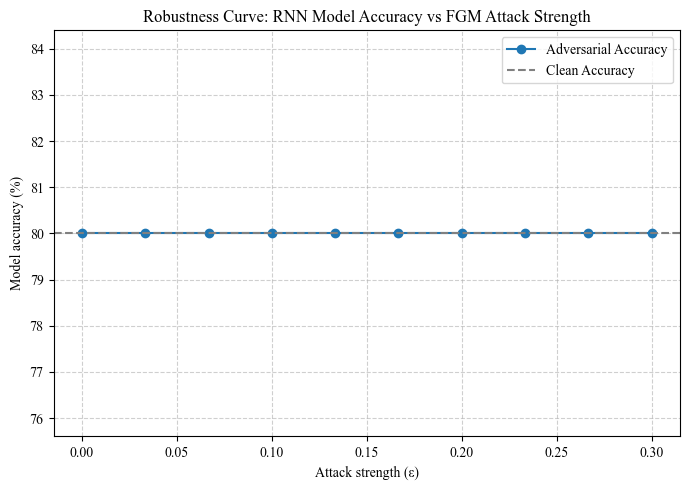

In [40]:
# Define a range of attack strengths
eps_values = np.linspace(0, 0.3, 10) # Test 10 steps from eps=0 to eps=0.3
accuracies = []

# --- FIX IS HERE ---
# y_test is already 1D
y_test_classes = y_test
# --- END FIX ---

print("Evaluating model robustness across different eps values...")

for eps in eps_values:
    # Set the attack strength
    attack_fgm.set_params(eps=eps)
    
    # Generate new adversarial examples
    X_test_adv = attack_fgm.generate(x=X_test)
    
    # Evaluate on the new adversarial data
    preds_adv = model.predict(X_test_adv)
    preds_adv_classes = np.argmax(preds_adv, axis=1)
    
    acc_adv = np.mean(preds_adv_classes == y_test_classes)
    accuracies.append(acc_adv)
    print(f"eps={eps:.3f} → Accuracy={acc_adv*100:.2f}%")

print(f"\nBaseline accuracy on CLEAN data: {accuracies[0]*100:.2f}%")

# === Plot robustness curve ===
plt.figure(figsize=(7, 5))
plt.plot(eps_values, np.array(accuracies) * 100, marker='o', label='Adversarial Accuracy')
plt.axhline(accuracies[0] * 100, color='gray', linestyle='--', label='Clean Accuracy')
plt.xlabel("Attack strength (ε)")
plt.ylabel("Model accuracy (%)")
plt.title("Robustness Curve: RNN Model Accuracy vs FGM Attack Strength")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()